# Plot - Representativeness

#### Load Data

In [1]:
import pandas as pd

df = pd.read_csv("../data/icpm_25/bpic_features.csv")
gen = pd.read_csv("../data/icpm_25/8fts_genEL_features.csv")
#gen = pd.read_csv("../../shampu/data/features/8_aq1_ekbr3_nusa_rt5v_svo_saq1_tlkh_tlv_allfeat.csv")

#paper_cols = ["log","ratio_variants_per_number_of_traces", "ratio_most_common_variant", 'ratio_top_10_variants', 'epa_normalized_variant_entropy', 'epa_normalized_sequence_entropy', 'epa_normalized_sequence_entropy_linear_forgetting', 'epa_normalized_sequence_entropy_exponential_forgetting'] 
paper_cols = list(set(gen.columns).intersection(set(df.columns)))
df= df[paper_cols]

print(gen.shape, df.shape)
print(len(gen.columns) == len(df.columns))
#print(gen.columns == df.columns)
print(gen.columns)
print(df.columns)
set(gen.columns).intersection(set(df.columns))


(58880, 10) (34, 8)
False
Index(['activities_q1', 'eventropy_k_block_ratio_3', 'log',
       'n_unique_start_activities', 'ratio_top_5_variants',
       'skewness_variant_occurrence', 'start_activities_q1',
       'target_similarity', 'trace_len_kurtosis_hist', 'trace_len_variance'],
      dtype='object')
Index(['log', 'activities_q1', 'trace_len_kurtosis_hist',
       'start_activities_q1', 'ratio_top_5_variants',
       'n_unique_start_activities', 'skewness_variant_occurrence',
       'trace_len_variance'],
      dtype='object')


{'activities_q1',
 'log',
 'n_unique_start_activities',
 'ratio_top_5_variants',
 'skewness_variant_occurrence',
 'start_activities_q1',
 'trace_len_kurtosis_hist',
 'trace_len_variance'}

In [2]:
df['source']='Real'
gen['source']='Generated'
both_df = pd.concat([df, gen])
print(both_df.shape)
both_df.head()

(58914, 11)


,log,activities_q1,trace_len_kurtosis_hist,start_activities_q1,ratio_top_5_variants,n_unique_start_activities,skewness_variant_occurrence,trace_len_variance,source,eventropy_k_block_ratio_3,target_similarity
0,BPI2016_Complaints,1.0,9.278209,1.0,0.283186,61.0,4.117031,0.413443,Real,NaN,NaN
1,BPI2016_Questions,3.0,17.551733,1.0,0.242419,809.0,46.205572,30.087560,Real,NaN,NaN
2,BPI2016_Werkmap_Messages,66058.0,20.216967,16653.0,0.490722,1.0,3.621815,17.671024,Real,NaN,NaN
3,BPIC15_1,3.0,0.364237,1.0,0.072560,14.0,17.491441,288.372558,Real,NaN,NaN
4,BPIC15_2,3.0,0.804992,1.0,0.054087,14.0,14.283027,395.810090,Real,NaN,NaN


#### Data Preprocessing

In [3]:
import numpy as np
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_mean.fit(both_df.drop(['log','source'], axis=1))
imp_df = imp_mean.transform(both_df.drop(['log','source'], axis=1))
imp_df = pd.DataFrame(imp_df, columns = both_df.columns[2:])
print("Before:", len(both_df.loc[:, both_df.isna().any()].columns), "columns in", len(both_df.loc[:, both_df.isna().any()]), 'rows')
print("After:", len(imp_df.loc[:, imp_df.isna().any()].columns))

Before: 9 columns in 58914 rows
After: 0


#### Plot - Principal Component Analysis

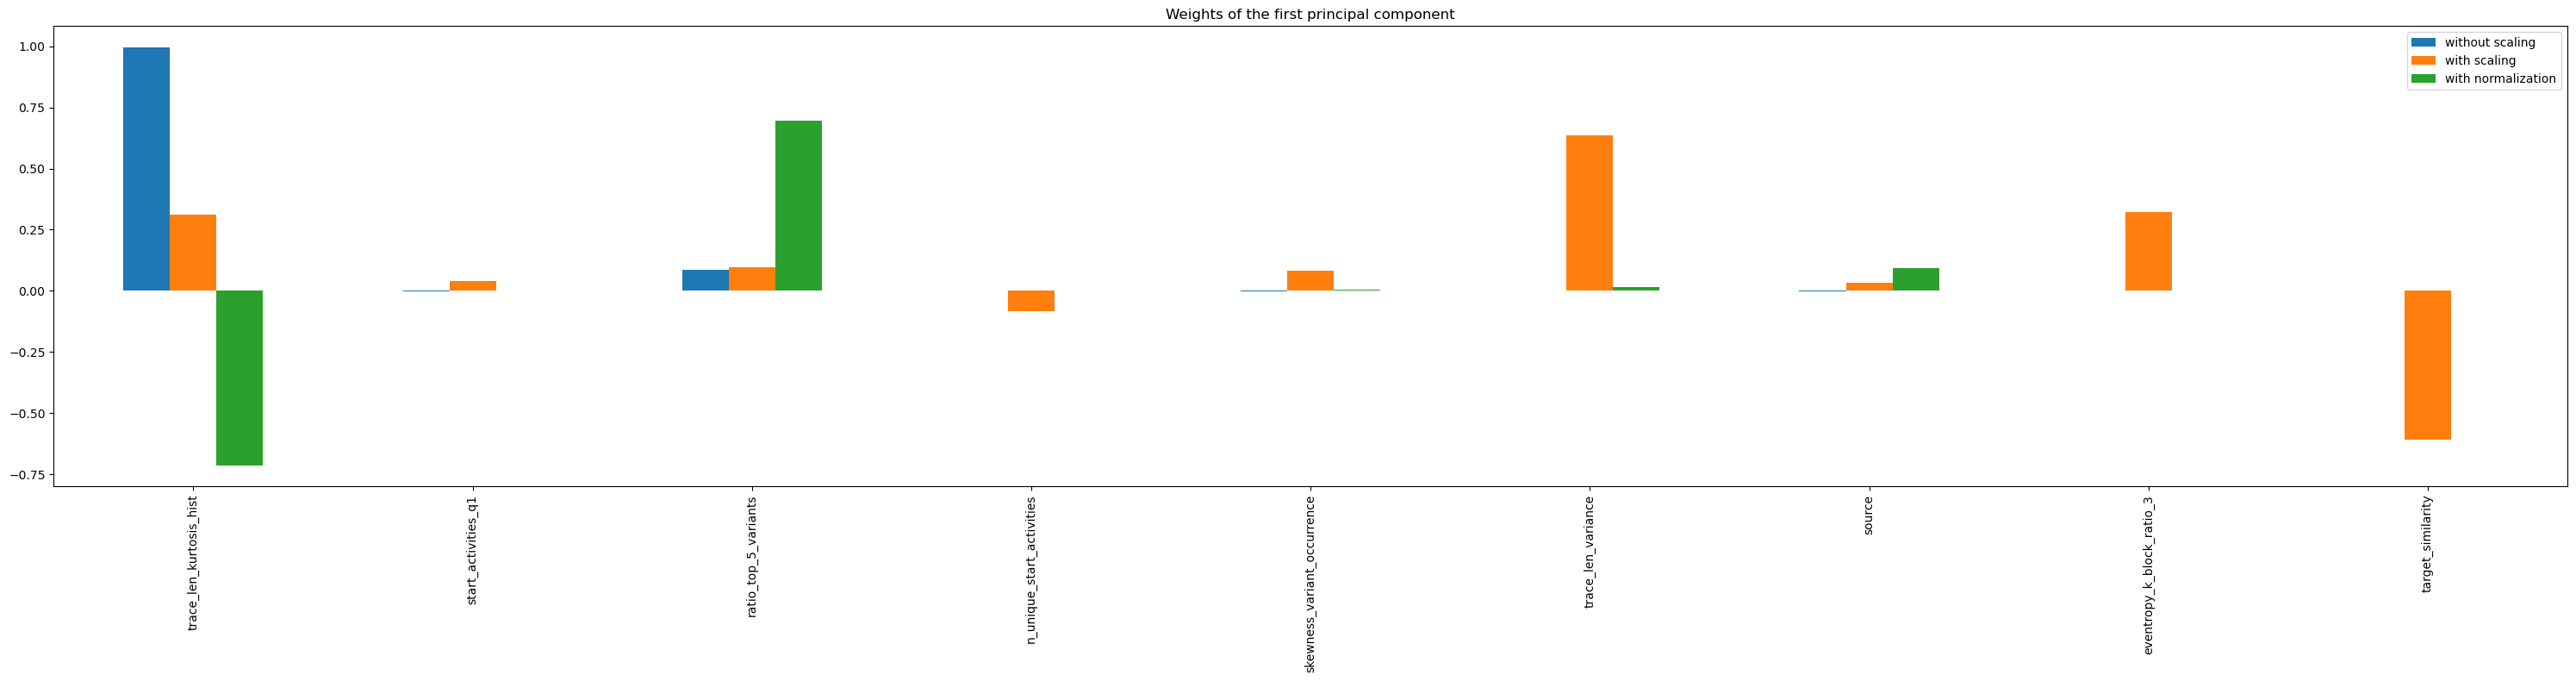

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer

X = imp_df
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X)
normed_X = Normalizer(norm="l2").fit_transform(X)


import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2).fit(X)
scaled_pca = PCA(n_components=2).fit(scaled_X_train)
norm_pca = PCA(n_components=2).fit(normed_X)


X_train_transformed = pca.transform(X)
X_train_std_transformed = scaled_pca.transform(scaled_X_train)
X_train_norm_transformed = norm_pca.transform(normed_X)


first_pca_component = pd.DataFrame(
    pca.components_[0], index=X.columns, columns=["without scaling"]
)
first_pca_component["with scaling"] = scaled_pca.components_[0]
first_pca_component["with normalization"] = norm_pca.components_[0]
first_pca_component.plot.bar(
    title="Weights of the first principal component", figsize=(30, 8)
)

_ = plt.tight_layout()

#### Plot - Convex hull of $1^{st}$ and $2^{nd}$ principal component

../output/plots/pca_BaselineED_GenED.png


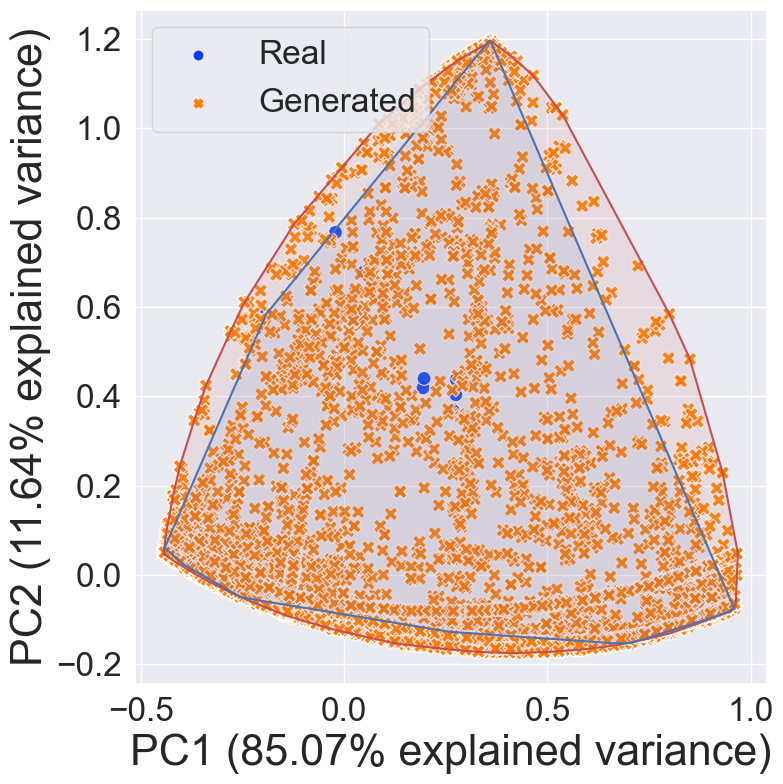

In [5]:
import numpy as np
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull

FONT_SIZE=24
FONTSIZE=24

def plot_convex_hull(numbers, ax, style, color):
    hull = ConvexHull(numbers)
    for simplex in hull.simplices:
        ax.plot(numbers[simplex, 0], numbers[simplex, 1], style)
    ax.fill(numbers[hull.vertices,0], numbers[hull.vertices,1], color, alpha=0.1)

pca = PCA(n_components=2)

# Normalizer: By default, L2 normalization is applied to each observation so the that the values in a row have a unit norm. 
    # Unit norm with L2 means that if each element were squared and summed, the total would equal 1. 
    #Normalizer does transform all the features to values between -1 and 1. 
#norm_data = Normalizer(norm="l2").fit_transform(df.drop(["log"], axis=1))
norm_data = Normalizer(norm="l2").fit_transform(X)

sns.set_theme()
fig, ax1 = plt.subplots(1,1,figsize=(8, 8))

#X_new = pca.fit_transform(X)
X_new = pca.fit_transform(norm_data)

df_pca = pd.DataFrame(X_new, columns=["PC1", "PC2"])
df_pca['source']=both_df['source'].to_numpy()
numbers_gen = df_pca[df_pca['source'] == 'Generated'][['PC1', 'PC2']].to_numpy()
numbers_real = df_pca[df_pca['source'] == 'Real'][['PC1', 'PC2']].to_numpy()

sns.scatterplot(ax=ax1, data=df_pca, x="PC1", y="PC2", palette="bright", hue='source',
                alpha=0.9, s=100, style="source")
plot_convex_hull(numbers_gen, ax1, 'r-', 'r')
plot_convex_hull(numbers_real, ax1, 'b-', 'b')

ax1.set_xlabel(f"PC1 ({np.round(pca.explained_variance_ratio_[0]*100, 2)}% explained variance)", fontsize=FONT_SIZE+7)
ax1.set_ylabel(f"PC2 ({np.round(pca.explained_variance_ratio_[1]*100, 2)}% explained variance)", fontsize=FONT_SIZE+7)
ax1.tick_params(axis='both', which='major', labelsize=FONT_SIZE)
ax1.tick_params(axis='both', which='minor', labelsize=FONT_SIZE)
ax1.legend(prop={'size': FONT_SIZE})

plt.yticks(fontsize=FONTSIZE)
plt.xticks(fontsize=FONTSIZE)
plt.legend(fontsize=FONTSIZE)
#plt.xticks(rotation=-30)

plt.tight_layout()
output_path = f"../output/plots/pca_BaselineED_GenED.png"
print(output_path)
plt.savefig(output_path, dpi=300, transparent=True)